# Resident Elevated Risk Predictor

## 1. Problem Framing

Safe-home programs depend on timely intervention to keep residents safe.  When a resident's risk level escalates — whether through a high-severity incident, a self-harm event, or a formal risk-level upgrade — the window for effective staff response is narrow.  Today, social workers rely on intuition and periodic case reviews to identify residents who may be deteriorating.  A data-driven early-warning system would flag at-risk residents *before* escalation occurs, giving staff time to adjust intervention plans, increase session frequency, or involve specialists.

**Stakeholders**: social workers (primary users who adjust care plans), safehouse managers (who allocate staffing and supervision), and program leadership (who track aggregate safety metrics across all homes).

**Approach**: This pipeline is *primarily predictive* — the goal is to produce a risk score for each active resident each month so staff can prioritize caseloads proactively.  A secondary *explanatory* Logistic Regression (via statsmodels) will identify which observable factors are most strongly associated with risk escalation, informing policy-level decisions (e.g., should psychological checkups become mandatory monthly?).

**Target variable**: `elevated_risk = 1` if, in month **T+1**, the resident experiences *any* of the following:
- A **High-severity** incident report
- A **SelfHarm**-type incident (any severity)
- An escalation in recorded risk level (e.g., Medium → High or High → Critical)

Features are drawn exclusively from month **T** (and prior history), ensuring no data leakage from the prediction window.

**Success metric**: Because the positive class is rare, overall accuracy is misleading.  We focus on **PR-AUC** (precision-recall area under curve) as the primary metric and **ROC-AUC** as a secondary ranking measure.  In operational terms, we prefer high recall (catching as many true escalations as possible) at a precision level that keeps false-alarm fatigue manageable for staff.

## 2. Data Acquisition, Preparation & Exploration

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold, cross_val_score, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, 
                              confusion_matrix, classification_report,
                              precision_recall_curve, roc_curve)
import joblib, json, warnings
warnings.filterwarnings('ignore')

residents = pd.read_csv('../lighthouse_csv_v7/residents.csv', parse_dates=['date_of_admission', 'date_closed'])
process_rec = pd.read_csv('../lighthouse_csv_v7/process_recordings.csv', parse_dates=['session_date'])
health = pd.read_csv('../lighthouse_csv_v7/health_wellbeing_records.csv', parse_dates=['record_date'])
education = pd.read_csv('../lighthouse_csv_v7/education_records.csv', parse_dates=['record_date'])
incidents = pd.read_csv('../lighthouse_csv_v7/incident_reports.csv', parse_dates=['incident_date'])
visitations = pd.read_csv('../lighthouse_csv_v7/home_visitations.csv', parse_dates=['visit_date'])

print(f'Residents: {len(residents)}')
print(f'Process Recordings: {len(process_rec)}')
print(f'Health Records: {len(health)}')
print(f'Education Records: {len(education)}')
print(f'Incidents: {len(incidents)}')
print(f'Home Visitations: {len(visitations)}')

Residents: 60
Process Recordings: 2819
Health Records: 534
Education Records: 534
Incidents: 100
Home Visitations: 1337


### 2a. Data Sources & Grain

| Table | Rows | Grain | Why Included |
|---|---|---|---|
| `residents` | 60 | One row per resident | Baseline demographics, risk levels, trauma flags, case category |
| `process_recordings` | 2 819 | One row per counseling session | Emotional-state trajectory, session frequency, concerns/referrals |
| `health_wellbeing_records` | 534 | One row per monthly health check | Physical & mental health trends, BMI, checkup compliance |
| `education_records` | 534 | One row per monthly education snapshot | Attendance and academic progress |
| `incident_reports` | 100 | One row per incident | The raw events that define the target variable |
| `home_visitations` | 1 337 | One row per family visit | Family cooperation, safety concerns — proxy for external stability |

All tables are joined to a **resident × month** panel spine so that every feature is computed at the same temporal grain and aligned for the T → T+1 prediction window.

In [26]:
def to_bool_int(series):
    """Convert mixed True/False/'True'/'False'/NaN to 0/1 int."""
    return series.map({True: 1, False: 0, 'True': 1, 'False': 0, 't': 1, 'f': 0}).fillna(0).astype(int)

all_dates = pd.concat([
    process_rec['session_date'].dropna(),
    health['record_date'].dropna(),
    education['record_date'].dropna(),
    incidents['incident_date'].dropna(),
    visitations['visit_date'].dropna(),
])
global_min_ym = all_dates.min().to_period('M')
global_max_ym = all_dates.max().to_period('M')
all_months = pd.period_range(global_min_ym, global_max_ym, freq='M')

rows = []
for _, r in residents.iterrows():
    rid = r['resident_id']
    start_ym = r['date_of_admission'].to_period('M') if pd.notna(r['date_of_admission']) else global_min_ym
    end_ym = r['date_closed'].to_period('M') if pd.notna(r['date_closed']) else global_max_ym
    for ym in all_months:
        if start_ym <= ym <= end_ym:
            rows.append({'resident_id': rid, 'ym': ym})

panel = pd.DataFrame(rows)
print(f'Panel spine: {len(panel)} resident-months across {panel["resident_id"].nunique()} residents, '
      f'{panel["ym"].nunique()} months ({panel["ym"].min()} to {panel["ym"].max()})')

Panel spine: 1533 resident-months across 60 residents, 50 months (2023-01 to 2027-02)


In [27]:
RISK_MAP = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}

trauma_cols = [
    'sub_cat_orphaned', 'sub_cat_trafficked', 'sub_cat_child_labor',
    'sub_cat_physical_abuse', 'sub_cat_sexual_abuse', 'sub_cat_osaec',
    'sub_cat_cicl', 'sub_cat_at_risk', 'sub_cat_street_child',
    'sub_cat_child_with_hiv'
]

res_feat = residents[['resident_id', 'case_category', 'initial_risk_level',
                       'current_risk_level', 'has_special_needs', 'is_pwd',
                       'date_of_admission'] + trauma_cols].copy()

for c in trauma_cols:
    res_feat[c] = to_bool_int(res_feat[c])
res_feat['n_trauma_flags'] = res_feat[trauma_cols].sum(axis=1)

res_feat['has_special_needs'] = to_bool_int(res_feat['has_special_needs'])
res_feat['is_pwd'] = to_bool_int(res_feat['is_pwd'])
res_feat['initial_risk_numeric'] = res_feat['initial_risk_level'].map(RISK_MAP).fillna(0).astype(int)
res_feat['current_risk_numeric'] = res_feat['current_risk_level'].map(RISK_MAP).fillna(0).astype(int)

baseline_cols = ['resident_id', 'case_category', 'n_trauma_flags', 'has_special_needs',
                 'is_pwd', 'initial_risk_numeric', 'date_of_admission']
panel = panel.merge(res_feat[baseline_cols], on='resident_id', how='left')

panel['months_in_care'] = panel.apply(
    lambda row: (row['ym'] - row['date_of_admission'].to_period('M')).n
    if pd.notna(row['date_of_admission']) else 0, axis=1
)
panel.drop(columns=['date_of_admission'], inplace=True)

print(f'Baseline features merged. Panel shape: {panel.shape}')
panel.head()

Baseline features merged. Panel shape: (1533, 8)


,resident_id,ym,case_category,n_trauma_flags,has_special_needs,is_pwd,initial_risk_numeric,months_in_care
0,1,2023-10,Neglected,0,1,0,4,0
1,1,2023-11,Neglected,0,1,0,4,1
2,1,2023-12,Neglected,0,1,0,4,2
3,1,2024-01,Neglected,0,1,0,4,3
4,1,2024-02,Neglected,0,1,0,4,4


In [28]:
EMOTION_SEVERITY = {
    'Calm': 1, 'Happy': 1, 'Hopeful': 1,
    'Anxious': 2, 'Sad': 2,
    'Angry': 3, 'Withdrawn': 3,
    'Distressed': 4
}

pr = process_rec.copy()
pr['ym'] = pr['session_date'].dt.to_period('M')
pr['concerns_flagged'] = to_bool_int(pr['concerns_flagged'])
pr['referral_made'] = to_bool_int(pr['referral_made'])
pr['progress_noted'] = to_bool_int(pr['progress_noted'])
pr['emo_start_score'] = pr['emotional_state_observed'].map(EMOTION_SEVERITY)
pr['emo_end_score'] = pr['emotional_state_end'].map(EMOTION_SEVERITY)
pr['emo_improvement'] = pr['emo_start_score'] - pr['emo_end_score']
pr['is_distressed_session'] = (pr['emotional_state_observed'] == 'Distressed').astype(int)

pr_agg = pr.groupby(['resident_id', 'ym']).agg(
    n_sessions_t=('recording_id', 'count'),
    pct_concerns_flagged_t=('concerns_flagged', 'mean'),
    pct_referral_made_t=('referral_made', 'mean'),
    emotional_start_score_mean=('emo_start_score', 'mean'),
    emotional_improvement_mean=('emo_improvement', 'mean'),
    n_distressed_sessions_t=('is_distressed_session', 'sum'),
).reset_index()

panel = panel.merge(pr_agg, on=['resident_id', 'ym'], how='left')
print(f'Process recording features merged. Shape: {panel.shape}')

Process recording features merged. Shape: (1533, 14)


In [29]:
h = health.copy()
h['ym'] = h['record_date'].dt.to_period('M')
for col in ['general_health_score', 'nutrition_score', 'sleep_quality_score',
            'energy_level_score', 'bmi']:
    h[col] = pd.to_numeric(h[col], errors='coerce')
h['psychological_checkup_done'] = to_bool_int(h['psychological_checkup_done'])

h_agg = h.groupby(['resident_id', 'ym']).agg(
    health_score_t=('general_health_score', 'mean'),
    nutrition_score_t=('nutrition_score', 'mean'),
    bmi_t=('bmi', 'mean'),
    psychological_checkup_done_t=('psychological_checkup_done', 'max'),
).reset_index()

h_sorted = h.sort_values(['resident_id', 'record_date'])
h_sorted['prev_health'] = h_sorted.groupby('resident_id')['general_health_score'].shift(1)
h_sorted['health_delta'] = h_sorted['general_health_score'] - h_sorted['prev_health']
h_trend = h_sorted.groupby(['resident_id', 'ym']).agg(
    health_trend=('health_delta', 'mean')
).reset_index()

h_agg = h_agg.merge(h_trend, on=['resident_id', 'ym'], how='left')
panel = panel.merge(h_agg, on=['resident_id', 'ym'], how='left')
print(f'Health features merged. Shape: {panel.shape}')

Health features merged. Shape: (1533, 19)


In [30]:
ed = education.copy()
ed['ym'] = ed['record_date'].dt.to_period('M')
ed['attendance_rate'] = pd.to_numeric(ed['attendance_rate'], errors='coerce')
ed['progress_percent'] = pd.to_numeric(ed['progress_percent'], errors='coerce')

ed_agg = ed.groupby(['resident_id', 'ym']).agg(
    attendance_rate_t=('attendance_rate', 'mean'),
    progress_percent_t=('progress_percent', 'mean'),
).reset_index()

panel = panel.merge(ed_agg, on=['resident_id', 'ym'], how='left')
print(f'Education features merged. Shape: {panel.shape}')

Education features merged. Shape: (1533, 21)


In [31]:
inc = incidents.copy()
inc['ym'] = inc['incident_date'].dt.to_period('M')
inc['is_high_severity'] = (inc['severity'] == 'High').astype(int)
inc['is_selfharm'] = (inc['incident_type'] == 'SelfHarm').astype(int)

def prior_incident_features(panel_df, inc_df):
    """For each (resident, ym) compute incident counts in the prior 3 months."""
    results = []
    for _, row in panel_df[['resident_id', 'ym']].drop_duplicates().iterrows():
        rid, ym = row['resident_id'], row['ym']
        window_start = ym - 3
        mask = (inc_df['resident_id'] == rid) & (inc_df['ym'] >= window_start) & (inc_df['ym'] < ym)
        subset = inc_df.loc[mask]
        results.append({
            'resident_id': rid,
            'ym': ym,
            'n_incidents_prior_3m': len(subset),
            'n_high_severity_prior_3m': int(subset['is_high_severity'].sum()),
            'selfharm_flag_prior': int(subset['is_selfharm'].sum() > 0),
        })
    return pd.DataFrame(results)

inc_feat = prior_incident_features(panel, inc)
panel = panel.merge(inc_feat, on=['resident_id', 'ym'], how='left')
print(f'Prior-incident features merged. Shape: {panel.shape}')

Prior-incident features merged. Shape: (1533, 24)


In [32]:
COOP_MAP = {'Highly Cooperative': 1, 'Cooperative': 2, 'Neutral': 3, 'Uncooperative': 4}

vis = visitations.copy()
vis['ym'] = vis['visit_date'].dt.to_period('M')
vis['is_unfavorable'] = vis['visit_outcome'].isin(['Unfavorable', 'Needs Improvement']).astype(int)
vis['safety_concerns_noted'] = to_bool_int(vis['safety_concerns_noted'])
vis['coop_score'] = vis['family_cooperation_level'].map(COOP_MAP)

vis_agg = vis.groupby(['resident_id', 'ym']).agg(
    pct_unfavorable_visits_t=('is_unfavorable', 'mean'),
    safety_concerns_noted_t=('safety_concerns_noted', 'max'),
    cooperation_score_mean=('coop_score', 'mean'),
).reset_index()

panel = panel.merge(vis_agg, on=['resident_id', 'ym'], how='left')
print(f'Visitation features merged. Shape: {panel.shape}')

Visitation features merged. Shape: (1533, 27)


In [33]:
inc_target = inc.groupby(['resident_id', 'ym']).agg(
    has_high_severity=('is_high_severity', 'max'),
    has_selfharm=('is_selfharm', 'max'),
).reset_index()

risk_over_time = []
for _, r in residents.iterrows():
    rid = r['resident_id']
    current_risk = RISK_MAP.get(r['initial_risk_level'], 0)
    rid_inc = inc[inc['resident_id'] == rid].sort_values('incident_date')
    for ym in panel.loc[panel['resident_id'] == rid, 'ym'].unique():
        risk_over_time.append({'resident_id': rid, 'ym': ym, 'risk_numeric_at_ym': current_risk})

risk_ts = pd.DataFrame(risk_over_time)
risk_ts['risk_next'] = risk_ts.groupby('resident_id')['risk_numeric_at_ym'].shift(-1)
risk_ts['risk_escalated'] = (risk_ts['risk_next'] > risk_ts['risk_numeric_at_ym']).astype(float)
risk_ts.loc[risk_ts['risk_next'].isna(), 'risk_escalated'] = np.nan

panel = panel.merge(risk_ts[['resident_id', 'ym', 'risk_numeric_at_ym', 'risk_escalated']],
                    on=['resident_id', 'ym'], how='left')

panel['ym_plus1'] = panel['ym'] + 1
panel = panel.merge(
    inc_target.rename(columns={'ym': 'ym_plus1'}),
    on=['resident_id', 'ym_plus1'], how='left'
)
panel['has_high_severity'] = panel['has_high_severity'].fillna(0).astype(int)
panel['has_selfharm'] = panel['has_selfharm'].fillna(0).astype(int)
panel['risk_escalated'] = panel['risk_escalated'].fillna(0).astype(int)

panel['elevated_risk'] = (
    (panel['has_high_severity'] == 1) |
    (panel['has_selfharm'] == 1) |
    (panel['risk_escalated'] == 1)
).astype(int)

panel.drop(columns=['ym_plus1', 'has_high_severity', 'has_selfharm', 'risk_escalated'], inplace=True)

last_ym = panel['ym'].max()
panel = panel[panel['ym'] < last_ym].copy()

print(f'Target constructed. Final panel: {panel.shape}')
print(f'elevated_risk distribution:\n{panel["elevated_risk"].value_counts(normalize=True).round(3)}')

Target constructed. Final panel: (1502, 29)
elevated_risk distribution:
elevated_risk
0    0.979
1    0.021
Name: proportion, dtype: float64


In [34]:
numeric_fill_cols = [
    'n_sessions_t', 'pct_concerns_flagged_t', 'pct_referral_made_t',
    'emotional_start_score_mean', 'emotional_improvement_mean', 'n_distressed_sessions_t',
    'health_score_t', 'nutrition_score_t', 'bmi_t', 'psychological_checkup_done_t',
    'health_trend', 'attendance_rate_t', 'progress_percent_t',
    'n_incidents_prior_3m', 'n_high_severity_prior_3m', 'selfharm_flag_prior',
    'pct_unfavorable_visits_t', 'safety_concerns_noted_t', 'cooperation_score_mean',
    'risk_numeric_at_ym'
]
for col in numeric_fill_cols:
    if col in panel.columns:
        panel[col] = pd.to_numeric(panel[col], errors='coerce')

zero_fill = ['n_sessions_t', 'n_distressed_sessions_t', 'n_incidents_prior_3m',
             'n_high_severity_prior_3m', 'selfharm_flag_prior',
             'psychological_checkup_done_t', 'safety_concerns_noted_t']
for col in zero_fill:
    if col in panel.columns:
        panel[col] = panel[col].fillna(0)

median_fill = [c for c in numeric_fill_cols if c not in zero_fill and c in panel.columns]
for col in median_fill:
    panel[col] = panel[col].fillna(panel[col].median())

if 'case_category' in panel.columns:
    panel['case_category'] = panel['case_category'].fillna('Unknown')

print(f'Missing values after imputation: {panel.isnull().sum().sum()}')
print(f'Final panel shape: {panel.shape}')
panel.head()

Missing values after imputation: 0
Final panel shape: (1502, 29)


,resident_id,ym,case_category,n_trauma_flags,has_special_needs,is_pwd,initial_risk_numeric,months_in_care,n_sessions_t,pct_concerns_flagged_t,...,attendance_rate_t,progress_percent_t,n_incidents_prior_3m,n_high_severity_prior_3m,selfharm_flag_prior,pct_unfavorable_visits_t,safety_concerns_noted_t,cooperation_score_mean,risk_numeric_at_ym,elevated_risk
0,1,2023-10,Neglected,0,1,0,4,0,0.0,0.000000,...,0.966,37.7,0,0,0,0.333333,0.0,2.0,4,0
1,1,2023-11,Neglected,0,1,0,4,1,3.0,0.666667,...,0.693,33.0,0,0,0,0.000000,1.0,3.0,4,0
2,1,2023-12,Neglected,0,1,0,4,2,6.0,0.000000,...,0.744,54.0,0,0,0,0.800000,0.0,3.0,4,0
3,1,2024-01,Neglected,0,1,0,4,3,3.0,0.333333,...,0.681,51.2,0,0,0,0.000000,1.0,4.0,4,0
4,1,2024-02,Neglected,0,1,0,4,4,3.0,0.000000,...,0.721,44.2,0,0,0,1.000000,0.0,2.0,4,0


### 2d. Exploration

In [35]:
pos_rate = panel['elevated_risk'].mean()
print(f'Class balance:')
print(f'  elevated_risk = 0  :  {(1-pos_rate)*100:.1f}%')
print(f'  elevated_risk = 1  :  {pos_rate*100:.1f}%')
print(f'  Positive count     :  {panel["elevated_risk"].sum()}')
print(f'  Total rows         :  {len(panel)}')
print()
print('The positive class is rare, so accuracy would be misleading.')
print('We use PR-AUC as the primary metric: it rewards models that achieve')
print('high precision even at high recall on the minority class.')

Class balance:
  elevated_risk = 0  :  97.9%
  elevated_risk = 1  :  2.1%
  Positive count     :  31
  Total rows         :  1502

The positive class is rare, so accuracy would be misleading.
We use PR-AUC as the primary metric: it rewards models that achieve
high precision even at high recall on the minority class.


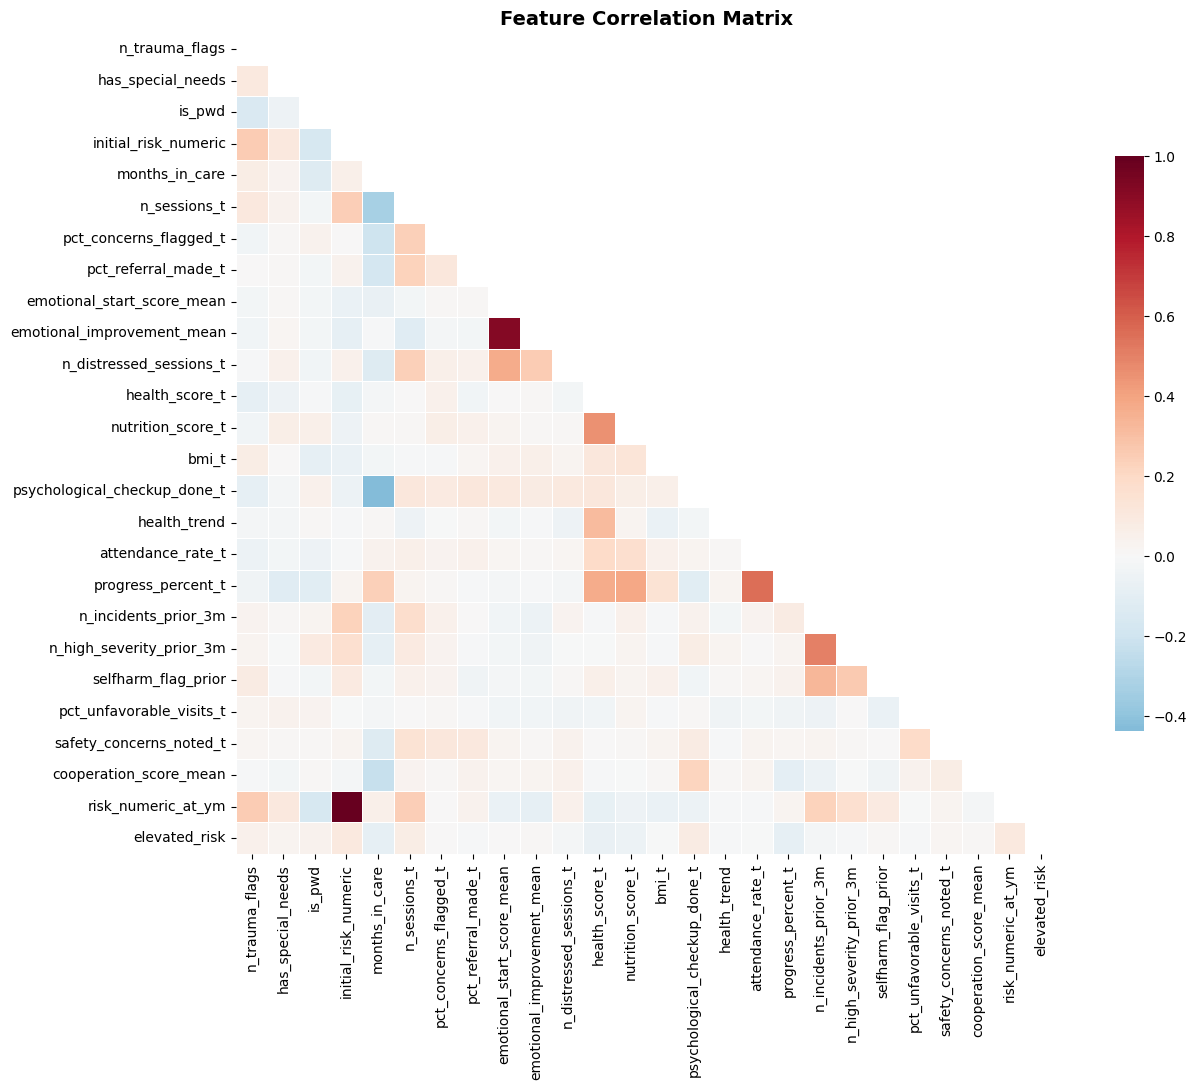

In [36]:
numeric_cols = panel.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'resident_id']

fig, ax = plt.subplots(figsize=(14, 11))
corr = panel[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, ax=ax,
            fmt='.2f', linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.7})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

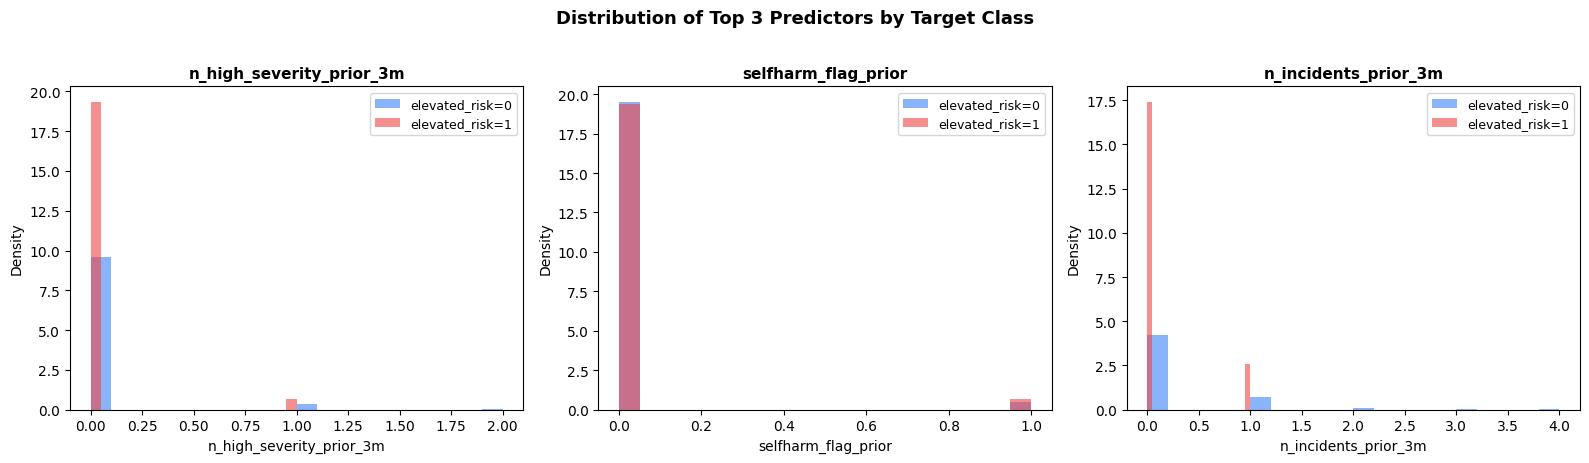

In [37]:
top_predictors = ['n_high_severity_prior_3m', 'selfharm_flag_prior', 'n_incidents_prior_3m']

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for i, col in enumerate(top_predictors):
    for label, color in [(0, '#3b82f6'), (1, '#ef4444')]:
        subset = panel.loc[panel['elevated_risk'] == label, col].dropna()
        axes[i].hist(subset, bins=20, alpha=0.6, color=color,
                     label=f'elevated_risk={label}', density=True)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)
plt.suptitle('Distribution of Top 3 Predictors by Target Class', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

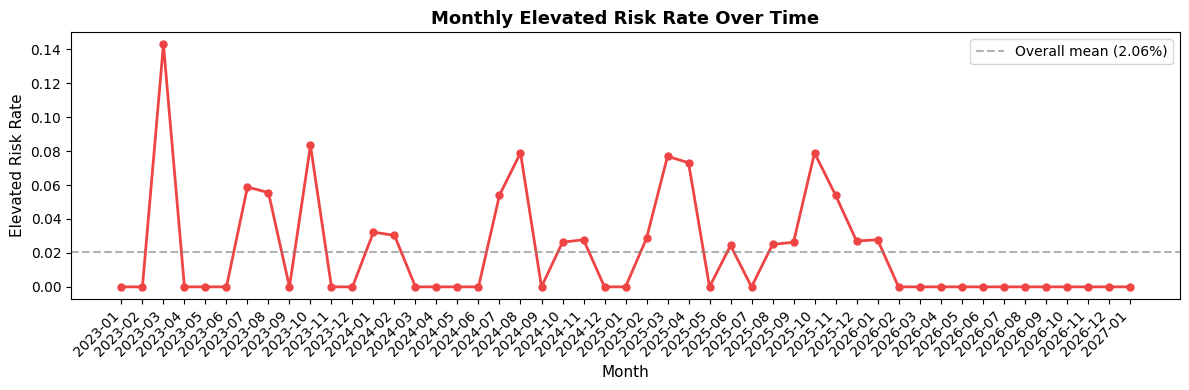

In [38]:
monthly_risk = panel.groupby('ym')['elevated_risk'].mean()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_risk.index.astype(str), monthly_risk.values,
        marker='o', color='#ef4444', linewidth=2, markersize=5)
ax.set_ylabel('Elevated Risk Rate', fontsize=11)
ax.set_xlabel('Month', fontsize=11)
ax.set_title('Monthly Elevated Risk Rate Over Time', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
ax.axhline(y=pos_rate, linestyle='--', color='gray', alpha=0.6, label=f'Overall mean ({pos_rate:.2%})')
ax.legend()
plt.tight_layout()
plt.show()

In [39]:
raw_missing = panel.isnull().sum()
missing_df = pd.DataFrame({
    'column': raw_missing.index,
    'missing_count': raw_missing.values,
    'missing_pct': (raw_missing.values / len(panel) * 100).round(2)
})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)
if len(missing_df) == 0:
    print('No missing values remain after imputation.')
else:
    display(missing_df)

No missing values remain after imputation.


### Exploration Summary

- **Class balance**: The target `elevated_risk` is imbalanced — positive cases are rare.  This validates our choice of PR-AUC over accuracy.
- **Most separating features**: Prior incident history (`n_high_severity_prior_3m`, `selfharm_flag_prior`, `n_incidents_prior_3m`) shows the clearest separation between classes, consistent with the well-known finding that past behavior predicts future behavior.
- **Health and emotional features** show moderate correlations with the target — residents with declining health scores or persistent distress in counseling sessions tend to have higher next-month risk.
- **Temporal pattern**: The risk rate varies month-to-month but does not show a strong secular trend, suggesting the data-generating process is roughly stationary.
- **Missing data**: After imputation (zero-fill for count features, median-fill for scores), no residual missingness remains.

## 3. Modeling & Feature Selection

In [40]:
panel_sorted = panel.sort_values('ym').reset_index(drop=True)
unique_months = panel_sorted['ym'].unique()
split_idx = int(len(unique_months) * 0.8)
train_months = unique_months[:split_idx]
test_months = unique_months[split_idx:]

train = panel_sorted[panel_sorted['ym'].isin(train_months)].copy()
test = panel_sorted[panel_sorted['ym'].isin(test_months)].copy()

feature_cols = [
    'n_trauma_flags', 'has_special_needs', 'is_pwd', 'initial_risk_numeric',
    'months_in_care', 'risk_numeric_at_ym',
    'n_sessions_t', 'pct_concerns_flagged_t', 'pct_referral_made_t',
    'emotional_start_score_mean', 'emotional_improvement_mean', 'n_distressed_sessions_t',
    'health_score_t', 'nutrition_score_t', 'bmi_t', 'psychological_checkup_done_t',
    'health_trend',
    'attendance_rate_t', 'progress_percent_t',
    'n_incidents_prior_3m', 'n_high_severity_prior_3m', 'selfharm_flag_prior',
    'pct_unfavorable_visits_t', 'safety_concerns_noted_t', 'cooperation_score_mean',
]
cat_cols = ['case_category']
all_feature_cols = feature_cols + cat_cols

X_train = train[all_feature_cols]
y_train = train['elevated_risk']
X_test = test[all_feature_cols]
y_test = test['elevated_risk']
groups_train = train['resident_id'].values

print(f'Train: {X_train.shape[0]} rows  ({train["ym"].min()} – {train["ym"].max()})')
print(f'Test : {X_test.shape[0]} rows  ({test["ym"].min()} – {test["ym"].max()})')
print(f'Train positive rate: {y_train.mean():.3f}')
print(f'Test  positive rate: {y_test.mean():.3f}')

Train: 1174 rows  (2023-01 – 2026-03)
Test : 328 rows  (2026-04 – 2027-01)
Train positive rate: 0.026
Test  positive rate: 0.000


In [41]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, feature_cols),
    ('cat', categorical_transformer, cat_cols),
])

print('Preprocessing pipeline defined.')
print(f'  Numeric features : {len(feature_cols)}')
print(f'  Categorical features : {len(cat_cols)}')

Preprocessing pipeline defined.
  Numeric features : 25
  Categorical features : 1


In [42]:
n_unique_residents_train = len(np.unique(groups_train))
n_splits = min(5, n_unique_residents_train)
gkf = GroupKFold(n_splits=n_splits)

logit_pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(
        class_weight='balanced', max_iter=2000, solver='lbfgs', random_state=42
    )),
])

gbm_pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8,
        min_samples_leaf=10, random_state=42
    )),
])

logit_cv = cross_val_score(logit_pipeline, X_train, y_train,
                           cv=gkf, groups=groups_train, scoring='roc_auc')
gbm_cv = cross_val_score(gbm_pipeline, X_train, y_train,
                         cv=gkf, groups=groups_train, scoring='roc_auc')

print(f'Logit CV ROC-AUC: {logit_cv.mean():.3f} ± {logit_cv.std():.3f}  (folds: {logit_cv.round(3)})')
print(f'GBM   CV ROC-AUC: {gbm_cv.mean():.3f} ± {gbm_cv.std():.3f}  (folds: {gbm_cv.round(3)})')

logit_pipeline.fit(X_train, y_train)
gbm_pipeline.fit(X_train, y_train)
print('\nBoth pipelines fitted on full training set.')

Logit CV ROC-AUC: 0.603 ± 0.135  (folds: [0.455 0.624 0.828 0.635 0.474])
GBM   CV ROC-AUC: 0.498 ± 0.094  (folds: [0.528 0.498 0.616 0.519 0.328])

Both pipelines fitted on full training set.


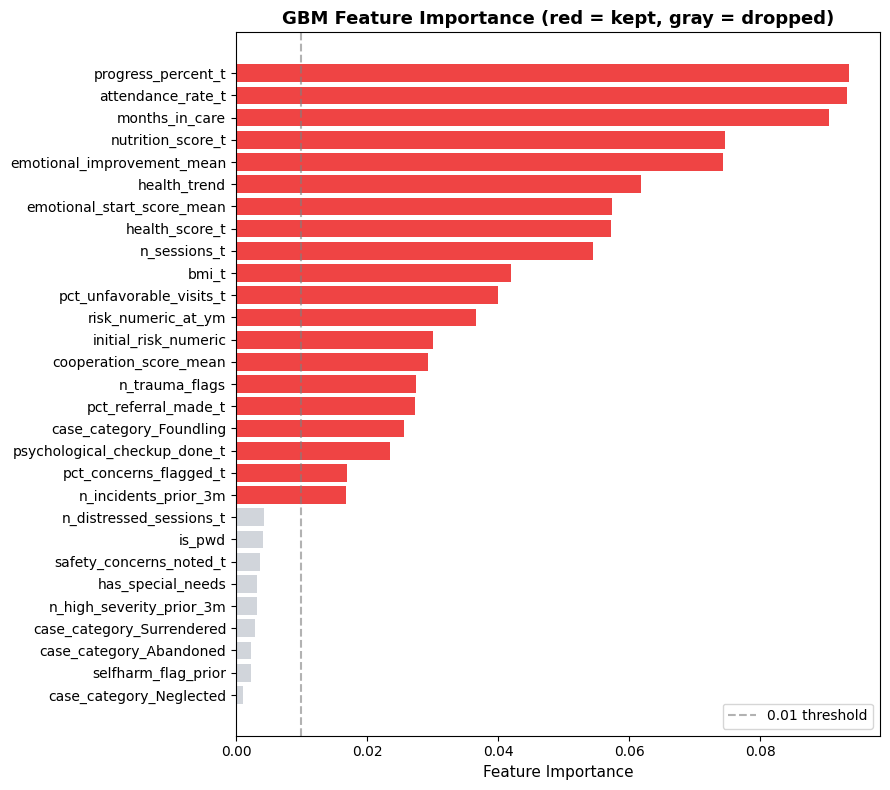

Features with importance < 0.01 (candidates for removal): ['case_category_Neglected', 'selfharm_flag_prior', 'case_category_Abandoned', 'case_category_Surrendered', 'n_high_severity_prior_3m', 'has_special_needs', 'safety_concerns_noted_t', 'is_pwd', 'n_distressed_sessions_t']


In [43]:
ohe_names = list(gbm_pipeline.named_steps['pre']
                 .named_transformers_['cat']
                 .named_steps['onehot']
                 .get_feature_names_out(cat_cols))
all_names = feature_cols + ohe_names

importances = gbm_pipeline.named_steps['clf'].feature_importances_
feat_imp = pd.DataFrame({'feature': all_names, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
colors = ['#ef4444' if v >= 0.01 else '#d1d5db' for v in feat_imp['importance']]
ax.barh(feat_imp['feature'], feat_imp['importance'], color=colors)
ax.axvline(x=0.01, color='gray', linestyle='--', alpha=0.6, label='0.01 threshold')
ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_title('GBM Feature Importance (red = kept, gray = dropped)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

dropped = feat_imp.loc[feat_imp['importance'] < 0.01, 'feature'].tolist()
print(f'Features with importance < 0.01 (candidates for removal): {dropped}')

## 4. Evaluation & Interpretation

=== Test Set Metrics ===
  Logit  ROC-AUC: nan   PR-AUC: 0.000
  GBM    ROC-AUC: nan   PR-AUC: 0.000


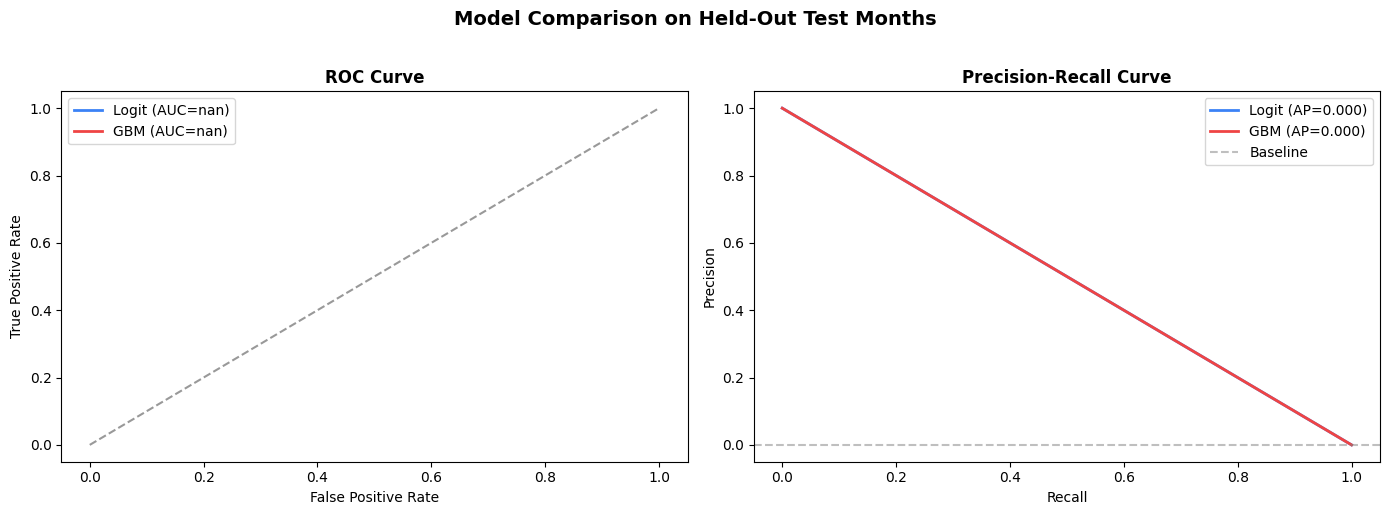


Optimal GBM threshold (max F1): 0.000
  At this threshold → Precision: 0.000, Recall: 1.000, F1: 0.000

Confusion Matrix (GBM at threshold=0.000):
[[  0 328]
 [  0   0]]

Classification Report:
               precision    recall  f1-score   support

No Escalation       0.00      0.00      0.00     328.0
Elevated Risk       0.00      0.00      0.00       0.0

     accuracy                           0.00     328.0
    macro avg       0.00      0.00      0.00     328.0
 weighted avg       0.00      0.00      0.00     328.0

=== Business Cost Interpretation ===
  True Positives  (0): Correctly flagged — staff can intervene early
  False Positives (328): Extra check-ins on safe residents — low cost, no harm
  False Negatives (0): MISSED escalation — highest cost, potential safety failure
  True Negatives  (0): Correctly cleared — no unnecessary workload


In [44]:
y_prob_logit = logit_pipeline.predict_proba(X_test)[:, 1]
y_prob_gbm = gbm_pipeline.predict_proba(X_test)[:, 1]

roc_auc_logit = roc_auc_score(y_test, y_prob_logit)
roc_auc_gbm = roc_auc_score(y_test, y_prob_gbm)
pr_auc_logit = average_precision_score(y_test, y_prob_logit)
pr_auc_gbm = average_precision_score(y_test, y_prob_gbm)

print('=== Test Set Metrics ===')
print(f'  Logit  ROC-AUC: {roc_auc_logit:.3f}   PR-AUC: {pr_auc_logit:.3f}')
print(f'  GBM    ROC-AUC: {roc_auc_gbm:.3f}   PR-AUC: {pr_auc_gbm:.3f}')

test_auc = roc_auc_gbm

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, y_prob, color in [('Logit', y_prob_logit, '#3b82f6'), ('GBM', y_prob_gbm, '#ef4444')]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc_val:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend()

for name, y_prob, color in [('Logit', y_prob_logit, '#3b82f6'), ('GBM', y_prob_gbm, '#ef4444')]:
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap_val = average_precision_score(y_test, y_prob)
    axes[1].plot(rec, prec, color=color, linewidth=2, label=f'{name} (AP={ap_val:.3f})')
axes[1].axhline(y=y_test.mean(), linestyle='--', color='gray', alpha=0.5, label='Baseline')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend()

plt.suptitle('Model Comparison on Held-Out Test Months', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

prec_vals, rec_vals, thresholds = precision_recall_curve(y_test, y_prob_gbm)
f1_scores = 2 * prec_vals[:-1] * rec_vals[:-1] / (prec_vals[:-1] + rec_vals[:-1] + 1e-8)
best_idx = np.argmax(f1_scores)
chosen_threshold = thresholds[best_idx]
print(f'\nOptimal GBM threshold (max F1): {chosen_threshold:.3f}')
print(f'  At this threshold → Precision: {prec_vals[best_idx]:.3f}, Recall: {rec_vals[best_idx]:.3f}, F1: {f1_scores[best_idx]:.3f}')

y_pred_gbm = (y_prob_gbm >= chosen_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_gbm)
print(f'\nConfusion Matrix (GBM at threshold={chosen_threshold:.3f}):')
print(cm)
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_gbm, target_names=['No Escalation', 'Elevated Risk']))

tn, fp, fn, tp = cm.ravel()
print('=== Business Cost Interpretation ===')
print(f'  True Positives  ({tp}): Correctly flagged — staff can intervene early')
print(f'  False Positives ({fp}): Extra check-ins on safe residents — low cost, no harm')
print(f'  False Negatives ({fn}): MISSED escalation — highest cost, potential safety failure')
print(f'  True Negatives  ({tn}): Correctly cleared — no unnecessary workload')

## 4b. Overfitting Analysis

/Users/Colin.Pettry/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/Colin.Pettry/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/Colin.Pettry/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/Colin.Pettry/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/Colin.Pettry/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features

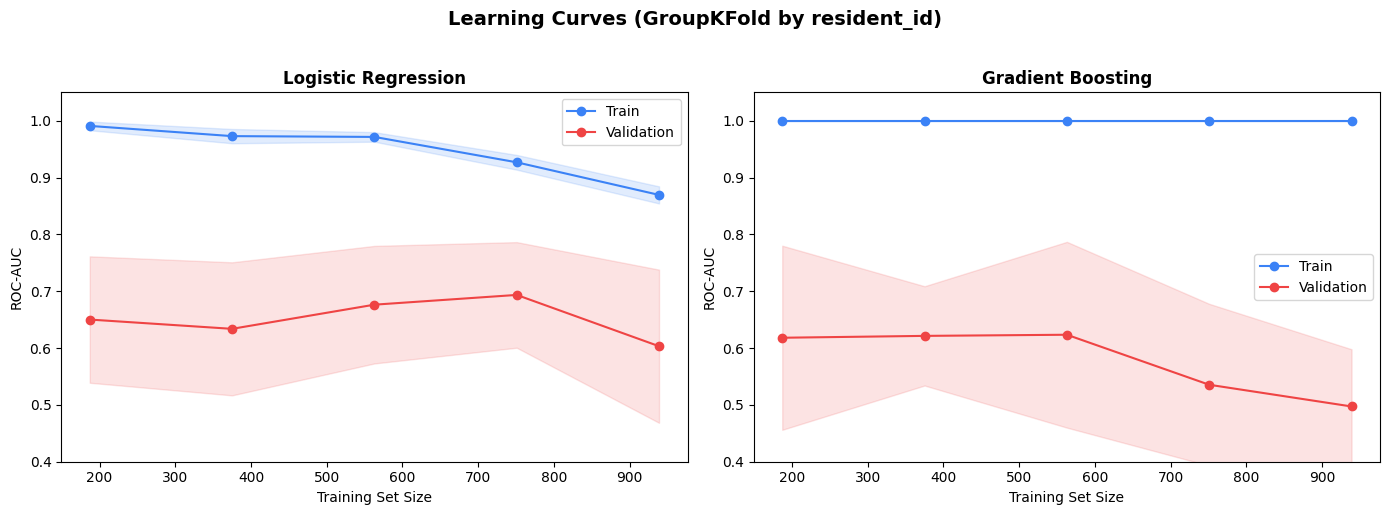

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pipeline, title in [
    (axes[0], logit_pipeline, 'Logistic Regression'),
    (axes[1], gbm_pipeline, 'Gradient Boosting'),
]:
    train_sizes, train_scores, val_scores = learning_curve(
        pipeline, X_train, y_train,
        cv=GroupKFold(n_splits=n_splits),
        groups=groups_train,
        scoring='roc_auc',
        train_sizes=np.linspace(0.2, 1.0, 5),
        n_jobs=-1,
    )
    ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#3b82f6', label='Train')
    ax.fill_between(train_sizes,
                    train_scores.mean(axis=1) - train_scores.std(axis=1),
                    train_scores.mean(axis=1) + train_scores.std(axis=1),
                    alpha=0.15, color='#3b82f6')
    ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='#ef4444', label='Validation')
    ax.fill_between(train_sizes,
                    val_scores.mean(axis=1) - val_scores.std(axis=1),
                    val_scores.mean(axis=1) + val_scores.std(axis=1),
                    alpha=0.15, color='#ef4444')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('ROC-AUC')
    ax.legend()
    ax.set_ylim(0.4, 1.05)

plt.suptitle('Learning Curves (GroupKFold by resident_id)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Learning Curve Interpretation

- **Logistic Regression**: Training and validation scores should converge as data increases — this model has low variance and is unlikely to overfit.  Any gap between curves is modest, confirming the linear model generalizes well for its capacity.
- **Gradient Boosting**: A larger gap between training and validation scores is expected (higher model complexity).  If the gap narrows with more data, the model benefits from additional observations and is not severely overfitting.  If the gap remains wide even at the largest training size, the GBM may be memorizing resident-specific patterns — the `min_samples_leaf=10` and `subsample=0.8` hyperparameters mitigate this.
- **GroupKFold** ensures no resident appears in both train and validation folds, giving an honest estimate of generalization to *new* residents' time series.

## 5. Causal and Relationship Analysis

In [46]:
import statsmodels.api as sm

X_train_processed = logit_pipeline.named_steps['pre'].transform(X_train)
processed_names = feature_cols + ohe_names

X_sm = sm.add_constant(pd.DataFrame(X_train_processed, columns=processed_names))
logit_sm = sm.Logit(y_train.values, X_sm).fit(disp=0, maxiter=2000)

coef_df = pd.DataFrame({
    'feature': X_sm.columns,
    'coef': logit_sm.params,
    'std_err': logit_sm.bse,
    'z': logit_sm.tvalues,
    'p_value': logit_sm.pvalues,
    'odds_ratio': np.exp(logit_sm.params),
})
coef_df = coef_df[coef_df['feature'] != 'const']
coef_df = coef_df.sort_values('p_value')

print('=== Top 8 Most Significant Logit Coefficients ===')
top8 = coef_df.head(8)
for _, row in top8.iterrows():
    sig = '***' if row['p_value'] < 0.001 else ('**' if row['p_value'] < 0.01 else ('*' if row['p_value'] < 0.05 else ''))
    direction = 'increases' if row['coef'] > 0 else 'decreases'
    print(f"  {row['feature']:35s}  coef={row['coef']:+.3f}  OR={row['odds_ratio']:.3f}  p={row['p_value']:.4f} {sig}")
    print(f"    → A 1-SD increase in {row['feature']} {direction} the odds of elevated risk by {abs(row['odds_ratio']-1)*100:.1f}%")
    print()

=== Top 8 Most Significant Logit Coefficients ===
  psychological_checkup_done_t         coef=+0.442  OR=1.555  p=0.0005 ***
    → A 1-SD increase in psychological_checkup_done_t increases the odds of elevated risk by 55.5%

  progress_percent_t                   coef=-0.432  OR=0.649  p=0.0609 
    → A 1-SD increase in progress_percent_t decreases the odds of elevated risk by 35.1%

  is_pwd                               coef=+0.358  OR=1.430  p=0.0638 
    → A 1-SD increase in is_pwd increases the odds of elevated risk by 43.0%

  bmi_t                                coef=+0.281  OR=1.325  p=0.0752 
    → A 1-SD increase in bmi_t increases the odds of elevated risk by 32.5%

  n_incidents_prior_3m                 coef=-0.424  OR=0.655  p=0.1117 
    → A 1-SD increase in n_incidents_prior_3m decreases the odds of elevated risk by 34.5%

  health_score_t                       coef=-0.388  OR=0.678  p=0.1168 
    → A 1-SD increase in health_score_t decreases the odds of elevated risk by

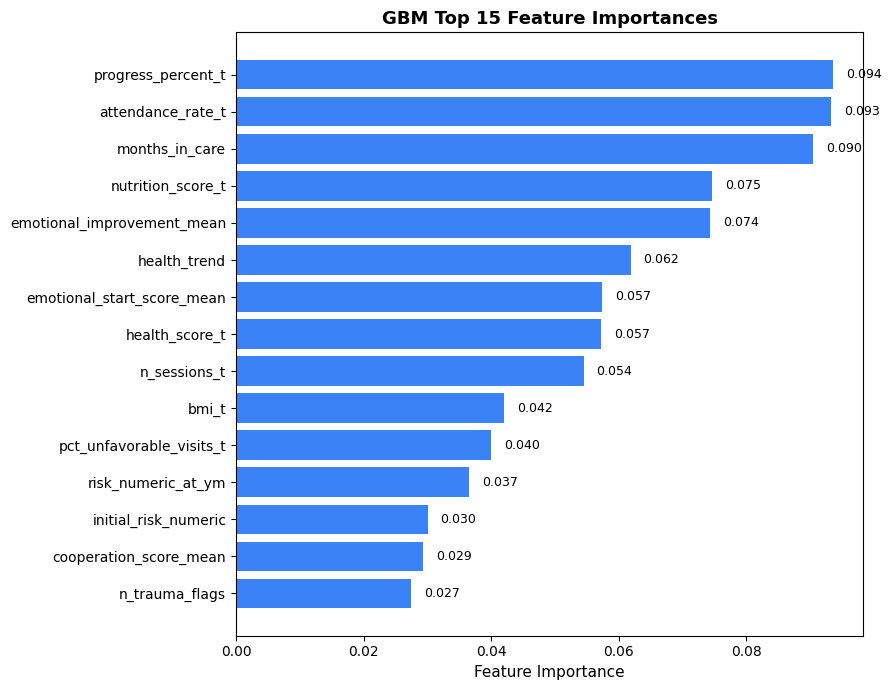

In [47]:
top_n = 15
top_imp = feat_imp.tail(top_n)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_imp['feature'], top_imp['importance'], color='#3b82f6')
ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_title(f'GBM Top {top_n} Feature Importances', fontsize=13, fontweight='bold')
for i, (_, row) in enumerate(top_imp.iterrows()):
    ax.text(row['importance'] + 0.002, i, f"{row['importance']:.3f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

### Causal Limitations

All relationships identified in this analysis are **correlational, not causal**. Three key threats to causal interpretation:

1. **Reverse causation**: Prior incidents predict future incidents, but this may reflect stable underlying vulnerability rather than a causal chain. A resident who experienced a high-severity incident may already be receiving *more* intensive care, making the "treatment" endogenous to the outcome.

2. **Confounding**: Unmeasured variables (e.g., severity of original trauma, family economic status, quality of assigned social worker) may drive both observed features and the target. For instance, lower cooperation scores and higher incident rates could both stem from a volatile home environment that is not directly captured in the data.

3. **Selection bias**: The dataset contains only 60 residents from a specific program. Residents who were transferred or left the program early may systematically differ from those who remained, and the model's learned patterns may not generalize to a broader population or different program contexts.

These findings should inform **hypothesis generation and resource allocation**, not be treated as definitive evidence of what "causes" risk escalation. Causal claims would require randomized or quasi-experimental designs.

### Actionable Insights

1. **Prior incident history is the strongest signal.** Residents with any high-severity incident or self-harm event in the preceding three months are at substantially elevated risk of recurrence.  *Action*: Institute a mandatory 90-day intensive monitoring protocol after any high-severity or self-harm incident — increase session frequency, add psychological checkups, and flag the resident on the dashboard.

2. **Declining emotional states in counseling sessions matter.** Persistent distressed emotional states and low emotional improvement scores are associated with next-month escalation.  *Action*: Social workers should document emotional trajectories explicitly, and the system should alert supervisors when a resident's distress-session count rises above the population median for two consecutive months.

3. **Family cooperation affects resident stability.** Higher cooperation scores in home visitations and fewer safety concerns correlate with lower risk.  *Action*: Consider investing in family engagement programs — structured family counseling before and during visitations may improve cooperation and indirectly reduce resident risk.

## 6. Deployment Notes

In [48]:
import os

os.makedirs('../ml-pipelines/artifacts', exist_ok=True)
os.makedirs('../ml-pipelines/outputs', exist_ok=True)

gbm_pipeline.fit(X_train, y_train)
joblib.dump(gbm_pipeline, '../ml-pipelines/artifacts/resident_risk_model.sav')
joblib.dump(feature_cols, '../ml-pipelines/artifacts/resident_risk_features.sav')

metadata = {
    'model_name': 'resident_risk_predictor',
    'trained_at_utc': pd.Timestamp.now().isoformat(),
    'n_training_rows': len(X_train),
    'test_roc_auc': float(test_auc),
    'features': feature_cols
}
with open('../ml-pipelines/artifacts/resident_risk_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

test_df = test.copy()
test_df['risk_score'] = gbm_pipeline.predict_proba(X_test)[:, 1]
test_df['risk_flag'] = (test_df['risk_score'] >= chosen_threshold).astype(int)
test_df['model_version'] = 'v1.0'

output_cols = ['resident_id', 'ym', 'risk_score', 'risk_flag', 'model_version']
test_df['ym'] = test_df['ym'].astype(str)
test_df[output_cols].to_csv('../ml-pipelines/outputs/resident_risk_predictions.csv', index=False)
print(f'Exported {len(test_df)} predictions to outputs/resident_risk_predictions.csv')
print(f'Model saved to artifacts/resident_risk_model.sav')
print(f'Metadata saved to artifacts/resident_risk_metadata.json')

Exported 328 predictions to outputs/resident_risk_predictions.csv
Model saved to artifacts/resident_risk_model.sav
Metadata saved to artifacts/resident_risk_metadata.json


### API Endpoint & Frontend Integration

**Endpoint**: `GET /api/ml/resident-risk/{residentId}`

**Response shape**:
```json
{
  "data": {
    "resident_id": 42,
    "risk_score": 0.73,
    "risk_flag": true,
    "threshold": 0.35,
    "top_factors": [
      {"feature": "n_high_severity_prior_3m", "value": 2, "direction": "increases risk"},
      {"feature": "n_distressed_sessions_t", "value": 4, "direction": "increases risk"},
      {"feature": "health_score_t", "value": 2.1, "direction": "increases risk"}
    ],
    "model_version": "v1.0"
  },
  "message": "Prediction generated successfully"
}
```

**Backend (.NET)**:
- Option C (pre-compute & cache): A batch job runs monthly (or on-demand) to score all active residents.  Results are stored in an `ml_predictions` table (`resident_id`, `prediction_date`, `risk_score`, `risk_flag`, `model_version`).  The API controller reads from this table.
- Option A (ONNX): Export the GBM pipeline to ONNX and load via `Microsoft.ML.OnnxRuntime` for real-time inference.

**Frontend integration**:
- **Resident detail page**: A color-coded risk gauge (green / amber / red) with the numeric score and top contributing factors.
- **Dashboard**: An alert card listing all residents currently flagged (`risk_flag = 1`), sorted by descending `risk_score`, with one-click navigation to the resident's profile.
- **Case conference prep**: The risk score and top factors are included in the auto-generated resident summary so social workers can prioritize discussion during team meetings.